# Project 03 — Revenue Decomposition

## Business Question

What mechanically drives revenue changes over time? Is growth driven by more customers, more orders per customer, or higher order values?

## Dataset

**Source:** [Online Retail II (Kaggle)](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

Transaction-level ecommerce data. The raw CSV is not included in this repository due to licensing constraints, but the analysis can be reproduced by downloading the dataset from Kaggle.

## Core Identity

Revenue = Active Customers × Orders per Customer × Average Order Value (AOV)

## Approach

1. Load and clean transaction data
2. Aggregate to monthly level
3. Calculate the three revenue components
4. Visualize each driver over time
5. Interpret which drivers explain revenue changes

**Important:** This is a **structural decomposition**, not a causal analysis. It shows what must have changed mechanically for revenue to change, but doesn't explain why.

### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("Imports loaded successfully")

Imports loaded successfully


### Load & Standardise Schema

Load the raw data and standardize column naming for consistency.

In [2]:
df = pd.read_csv("online_retail_II.csv", sep=";")

df = df.rename(columns={"Customer ID": "CustomerID"})

### Parse Dates

Convert invoice dates to datetime format.

In [3]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%y %H:%M",
    errors="coerce"
)
df.shape, df.columns

((541910, 8),
 Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
        'Price', 'CustomerID', 'Country'],
       dtype='str'))

### Clean transactions + construct Month & Revenue

Remove invalid transactions:
- Negative quantities or prices
- Cancelled invoices (starting with "C")
- Transactions without customer IDs
- Invalid dates


In [4]:
clean = (
    df
    .dropna(subset=["CustomerID", "InvoiceDate"])
    .query("Quantity > 0 and Price > 0")
    .assign(
        CustomerID=lambda x: x["CustomerID"].astype(int),
        Revenue=lambda x: x["Quantity"] * x["Price"],
        Month=lambda x: x["InvoiceDate"].dt.to_period("M")
    )
)

clean["Month"].nunique(), clean["Month"].min(), clean["Month"].max()


(13, Period('2010-12', 'M'), Period('2011-12', 'M'))

### Monthly Aggregation

Aggregate transaction data to monthly level and calculate the three revenue components:
- **Active Customers:** Unique customers who made at least one purchase
- **Orders per Customer:** Total orders divided by active customers
- **AOV (Average Order Value):** Revenue divided by total orders

In [5]:
monthly = (
    clean
    .groupby("Month")
    .agg(
        Revenue=("Revenue", "sum"),
        ActiveCustomers=("CustomerID", "nunique"),
        Orders=("Invoice", "nunique")
    )
    .reset_index()
    .sort_values("Month")
    .assign(
        OrdersPerCustomer=lambda x: x["Orders"] / x["ActiveCustomers"],
        AOV=lambda x: x["Revenue"] / x["Orders"]
    )
)

monthly.head()


,Month,Revenue,ActiveCustomers,Orders,OrdersPerCustomer,AOV
0,2010-12,572713.89,885,1400,1.581921,409.081350
1,2011-01,569445.04,741,987,1.331984,576.945329
2,2011-02,447137.35,758,997,1.315303,448.482798
3,2011-03,595500.76,974,1321,1.356263,450.795428
4,2011-04,469201.36,856,1149,1.342290,408.356275


### Verify Decomposition

Check that our decomposition reconstructs the original revenue correctly.

In [6]:
monthly = monthly.assign(
    ReconstructedRevenue=lambda x: x["ActiveCustomers"] * x["OrdersPerCustomer"] * x["AOV"]
)

relative_error = (
    (monthly["Revenue"] - monthly["ReconstructedRevenue"]).abs() / monthly["Revenue"]
).max()

relative_error


np.float64(1.1232429358228416e-16)

Small numerical differences are due to floating-point arithmetic and are not analytically meaningful.

### Resulting dataset
At this point, we have a monthly dataset containing:
- Revenue
- Active customers
- Orders
- Orders per customer
- Average order value (AOV)

This table fully decomposes revenue into its mechanical drivers
and forms the basis for interpretation.


In [7]:
monthly.head()

,Month,Revenue,ActiveCustomers,Orders,OrdersPerCustomer,AOV,ReconstructedRevenue
0,2010-12,572713.89,885,1400,1.581921,409.081350,572713.89
1,2011-01,569445.04,741,987,1.331984,576.945329,569445.04
2,2011-02,447137.35,758,997,1.315303,448.482798,447137.35
3,2011-03,595500.76,974,1321,1.356263,450.795428,595500.76
4,2011-04,469201.36,856,1149,1.342290,408.356275,469201.36


### Visualize Revenue Drivers

Plot each component over time to understand which drivers explain revenue changes.

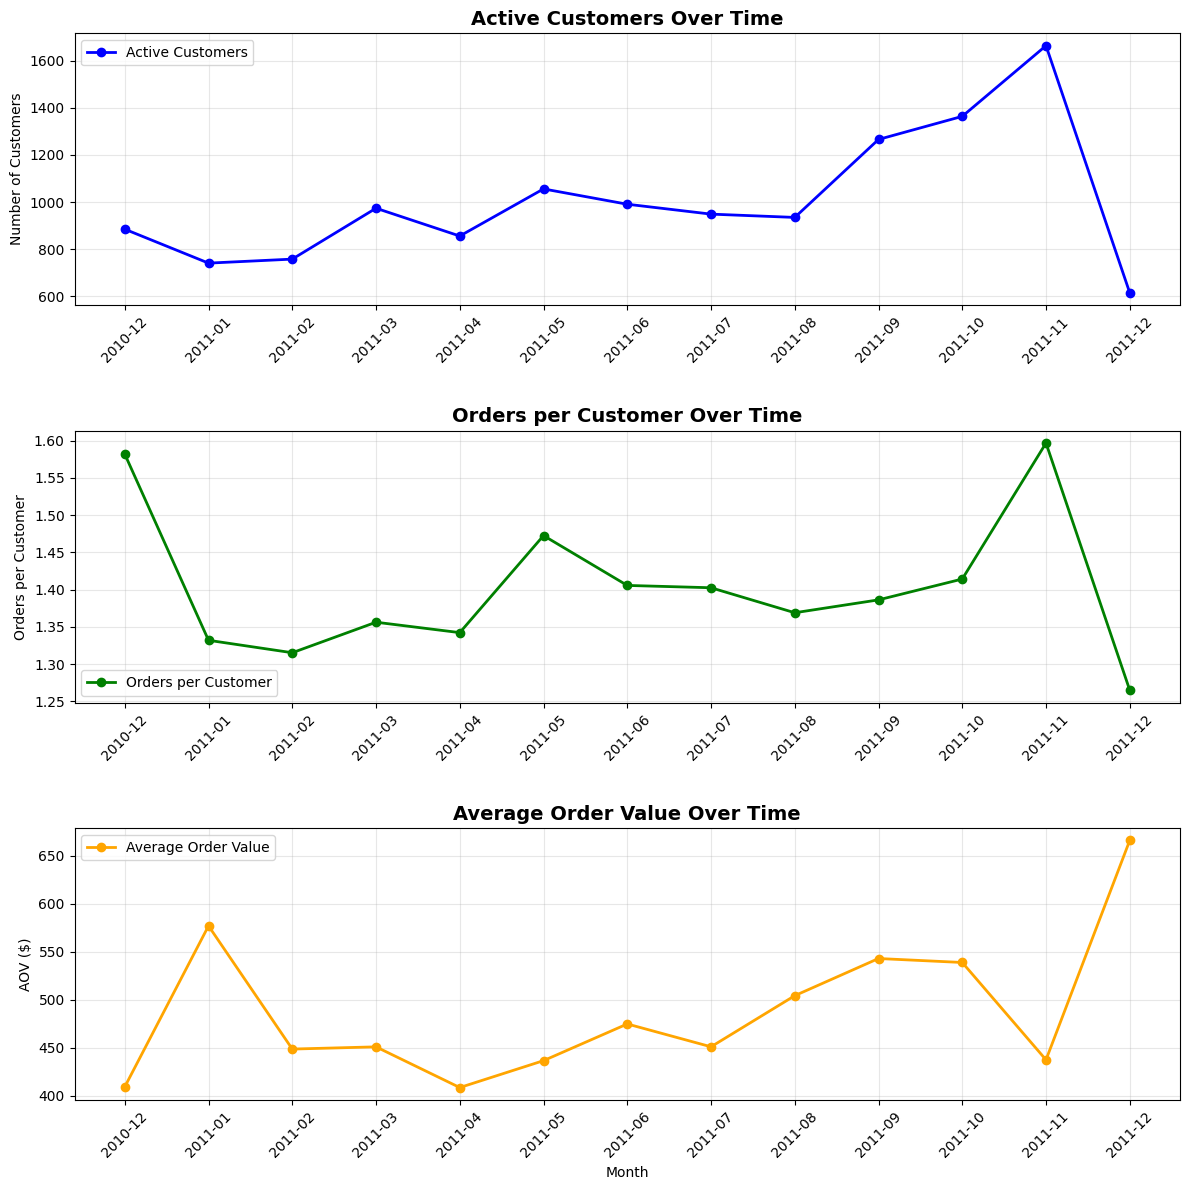

In [8]:
# Create subplots for all three revenue drivers
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Active Customers
axes[0].plot(monthly["Month"].astype(str), monthly["ActiveCustomers"], 
             label="Active Customers", marker='o', color='blue', linewidth=2)
axes[0].set_title("Active Customers Over Time", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Number of Customers")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Orders per Customer
axes[1].plot(monthly["Month"].astype(str), monthly["OrdersPerCustomer"], 
             label="Orders per Customer", marker='o', color='green', linewidth=2)
axes[1].set_title("Orders per Customer Over Time", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Orders per Customer")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Average Order Value
axes[2].plot(monthly["Month"].astype(str), monthly["AOV"], 
             label="Average Order Value", marker='o', color='orange', linewidth=2)
axes[2].set_title("Average Order Value Over Time", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Month")
axes[2].set_ylabel("AOV ($)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(h_pad=3.0)
plt.show()

### Interpreting the Drivers

**Key Findings:**

1. **Active Customers** is the dominant driver
   - Revenue co-moves strongly with active customer count
   - Customer participation drives most revenue variation

2. **Orders per Customer** reinforces trends
   - Tends to rise during peak periods
   - Amplifies the customer count effect rather than driving independently

3. **AOV** shows counter-cyclical behavior
   - Often moves opposite to volume (lower AOV in high-volume months)
   - Suggests product mix or pricing effects during promotional periods

**Important Caveat:**

This decomposition is **structural and descriptive** — it shows what must have changed mechanically for revenue to change, but it does **not** establish causality. To understand *why* these components changed would require additional analysis (e.g., marketing attribution, pricing experiments, seasonality controls).